# Reading and plotting **EOVSA flare spectrogram** and **images**

## Section 1: Download and Read the Data
* You can browse, query, and download the EOVSA spectrogram and spectral image data at [https://ovsa.njit.edu/flarelist](https://ovsa.njit.edu/flarelist).
* Alternatively, you can access them directly through the following links:
  * **Spectrogram data** can be accessed from [https://ovsa.njit.edu/events/](https://ovsa.njit.edu/events/) under the directory `YYYY`, with the file name format:  
    `eovsa.spec.flare_id_YYYYMMDDHHMMSS.fits`
    
    **Note:** All spectrogram data before mid-October 2024 are **cross-power data**. As advised, these cross-power spectrograms should only be used as a reference, such as for timing analysis, and are **not suitable for quantitative spectral analysis**. Starting from mid-October 2024, we provide both **total-power**(tp) and **cross-power**(xp) spectrogram data:
    * **TP spectrogram**:  `eovsa.spec_tp.flare_id_YYYYMMDDHHMM.fits`
    * **XP spectrogram**:  `eovsa.spec_xp.flare_id_YYYYMMDDHHMM.fits`
    
    We are currently working on further improving accessibility and quality of these data products.
  
  * **Spectral image data** can be accessed from [https://ovsa.njit.edu/fits/flares/](https://ovsa.njit.edu/fits/flares/) under `YYYY/MM/DD/[flare_id]/` with the file name format:  
    `"eovsa.lev1_mbd_12s.YYYY-MM-DDTHHMMSSZ.image.fits"`

* **Python Environment Recommendation:** This notebook has been tested on Python 3.8 and 3.10. Your mileage may vary (YMMV) with other Python versions.
* The only Python package required in this section is [Astropy](https://www.astropy.org/). You can install Astropy with the following command in python:  

In [1]:
  # !pip install astropy

### Enabling Interactive Backend for Matplotlib in Jupyter Notebooks

If you need an interactive backend for Matplotlib within Jupyter Notebooks, this block allows you to zoom, pan, and interact directly with the plot in the notebook cell. This can be especially useful for exploring complex data visualizations, such as spectrograms. If you only need to see a static version of the plot, you can skip this block and proceed with the standard `%matplotlib inline` for static plots.

The following code installs and enables the interactive plotting tools in Google Colab or Jupyter Notebooks:


In [2]:
# Install ipympl, which provides an interactive Matplotlib backend for Jupyter Notebooks
# !pip install ipympl

# Enable the custom widget manager in Google Colab for interactive widgets
# from google.colab import output
# output.enable_custom_widget_manager()

# Use the widget backend for interactive plots
%matplotlib widget

### Reading EOVSA Flare Spectrogram FITS File

In [4]:
from astropy.io import fits
from astropy.time import Time

eospec_file = 'https://ovsa.njit.edu/events/2026/eovsa.spec.flare_id_20260118175000.fits'  # Use the path to your spec FITS file

eospecfits = fits.open(eospec_file)
# The spectrogram data has a shape of (n_freq, nt) in solar flux units (sfu)
spec = eospecfits[0].data

# Get the frequency axis in GHz
fghz = eospecfits[1].data['fghz']

# Get the time axis in julian date
eotime_jd = eospecfits[2].data['time']
eotime = Time(eotime_jd, format='jd')

HTTPError: HTTP Error 403: Forbidden

### Reading EOVSA Multi-Frequency Flare Image FITS File

In [ ]:
from astropy.io import fits

# Path to the EOVSA flare multi-frequency image FITS file
eofits = 'https://ovsa.njit.edu/fits/flares/2024/02/10/20240210224700/eovsa.lev1_mbd_12s.2024-02-10T224711Z.image.fits'
hdu = fits.open(eofits)

# Extract image data from the 2nd HDU (index 1)
# The data shape is (n_freq, ny, nx), representing the number of frequencies, pixels in y, and pixels in x respectively
rdata = hdu[1].data
(nf, ny, nx) = rdata.shape
print(f'Number of frequencies: {nf}, Pixels in solar-Y: {ny}, Pixels in solar-X: {nx}')

# Extract frequency information from the 3rd HDU (index 2)
# 'cfreqs' contains the central frequency of each image in Hz, convert to GHz
cfreqs_ghz = hdu[2].data['cfreqs'] / 1e9

# 'cdelts' contains the bandwidth of each image in Hz, convert to GHz
bdw_ghz = hdu[2].data['cdelts'] / 1e9

# Print the central frequencies and bandwidths of each image in GHz
print('Central frequencies (GHz):', cfreqs_ghz)
print('Bandwidths (GHz):', bdw_ghz)

Number of frequencies: 9, Pixels in solar-Y: 512, Pixels in solar-X: 512
Central frequencies (GHz): [ 2.8737106  3.5208142  4.49208    5.1420646  6.7670255  8.391987
  9.691956  11.64191   13.2668705]
Bandwidths (GHz): [0.32460937 0.32421875 0.325      0.325      0.325      0.325
 0.325      0.325      0.325     ]


## Section 2: Examples of plotting the spectrogram and spectral images

Now you are all set to use your favorite method to plot the spectrograms and spectral images! Below, we provide some simple examples using [Matplotlib](https://matplotlib.org/) and [SunPy](https://sunpy.org/). Experienced users can skip this and dive straight into doing science!
### Installing SunPy (if not already installed)

In [ ]:
# If SunPy is not already installed in your environment, uncomment the lines below to install it.

# It is recommended to install the latest version of SunPy directly from the official SunPy GitHub repository
# to ensure compatibility and access to the newest features.
!pip install git+https://github.com/sunpy/sunpy.git

# Install the 'net' extra of SunPy for downloading FITS files from various instruments, including SDO/AIA.
!pip install sunpy[net]


  Cloning https://github.com/sunpy/sunpy.git to /tmp/pip-req-build-pjxg04o8
  Running command git clone --filter=blob:none --quiet https://github.com/sunpy/sunpy.git /tmp/pip-req-build-pjxg04o8
  Resolved https://github.com/sunpy/sunpy.git to commit 664d1c51901edbfda9f5ac4d8f23ab3a4a4daed1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


### Example: Plotting the EOVSA Spectrogram

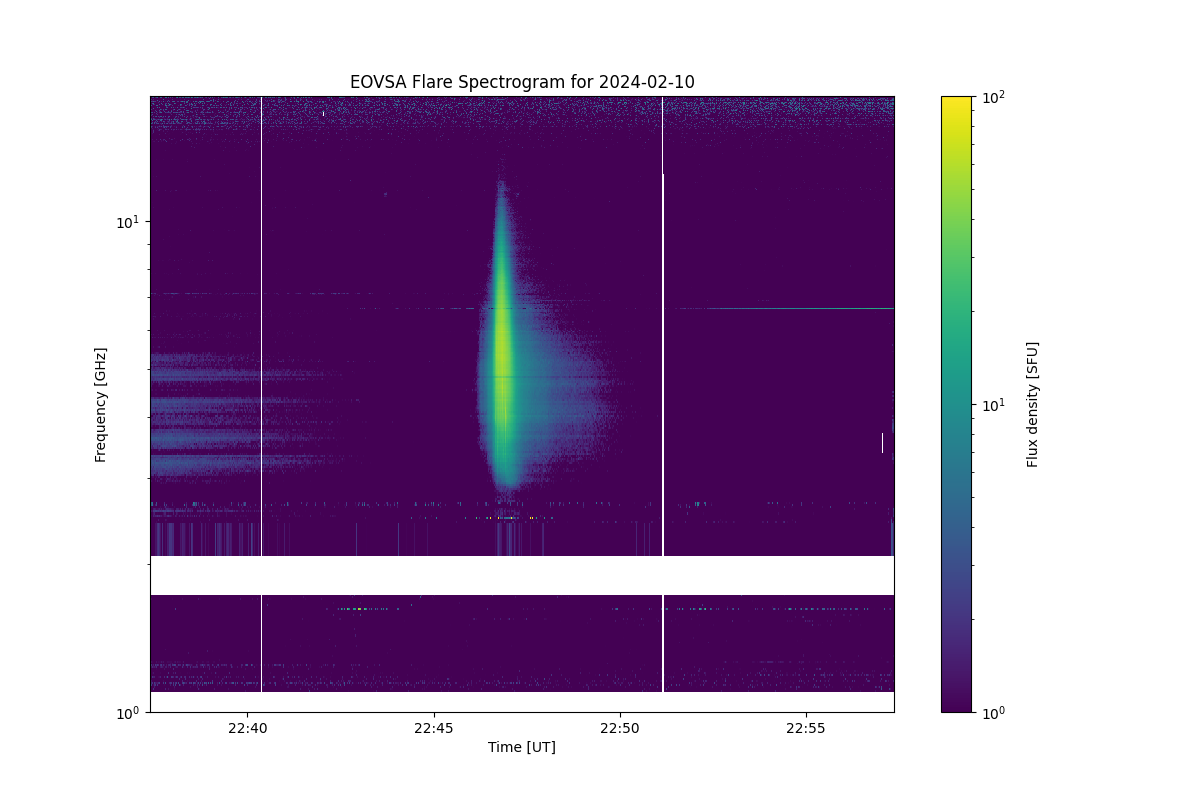

In [ ]:
from astropy.time import Time
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib
from matplotlib.dates import AutoDateFormatter, AutoDateLocator

# Convert time to plot date
eotime_pd = eotime.plot_date

# Set non-positive values in spectrogram to a small positive value for LogNorm
spec[spec <= 0] = 0.0001

# Plotting the spectrogram
fig, ax = plt.subplots(figsize=(12,8))

# Plot the spectrogram using a logarithmic color scale
ph = ax.pcolormesh(eotime_pd, fghz, spec, cmap='viridis',
                   norm=mcolors.LogNorm(vmax=100, vmin=1))

# Set the x-axis formatter and locator
locator = AutoDateLocator(minticks=5)
formatter = AutoDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)
formatter.scaled[1/(24*60)] = '%H:%M'  # Set specific format for minute scale

# Set y-axis limits and scale
ax.set_ylim(1, 18)  # Frequency range in GHz
ax.set_yscale('log')  # Set y-axis to logarithmic scale for better visibility of frequency range


# Set labels and title
plt.setp(ax, xlabel='Time [UT]', ylabel='Frequency [GHz]',
         xlim=[eotime_pd[0], eotime_pd[-1]],
         title='EOVSA Flare Spectrogram for ' + eotime[0].isot[:10])

# Add colorbar
cbar = plt.colorbar(ph, ax=ax)
cbar.set_label('Flux density [SFU]', labelpad=15)

# Show plot
plt.show()



### Example: Using `sunpy.map` to Plot EOVSA Flare Images

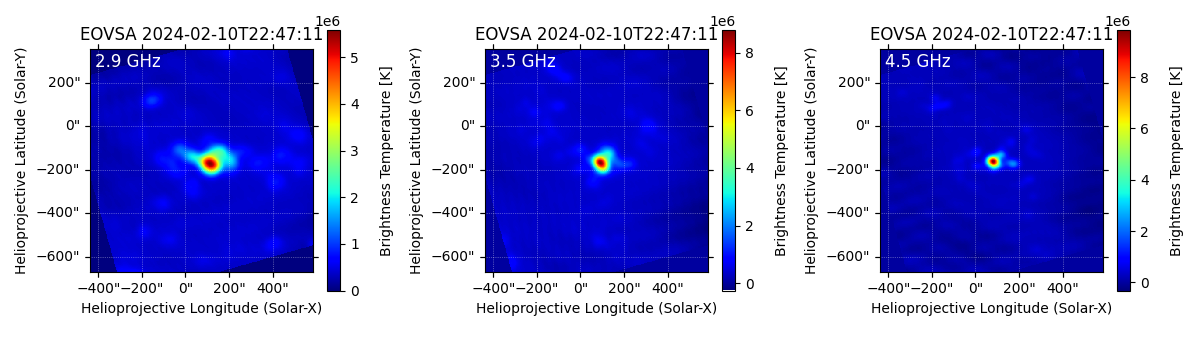

In [ ]:
import sunpy.map
import matplotlib.pyplot as plt

# Select frequency indices to plot. We have 9 frequencies in this example
spws = [0, 1, 2]

# Create a figure to plot the selected frequency images
fig = plt.figure(figsize=(12., 3.5))
for n, sp in enumerate(spws):
    data = rdata[sp, :, :]
    header = hdu[1].header
    rmap = sunpy.map.Map(data, header)
    ax = fig.add_subplot(1, len(spws), n+1, projection=rmap)

    # Plot the map and add a limb line
    rmap.plot(axes=ax, cmap='jet')
    rmap.draw_limb()

    # Set title and label each image with its frequency
    ax.set_title('EOVSA ' + rmap.date.datetime.strftime('%Y-%m-%dT%H:%M:%S'))
    ax.text(0.02, 0.98, "{:.1f}".format(cfreqs_ghz[sp]) + ' GHz',
            ha='left', va='top', transform=ax.transAxes, color='w', fontsize=12)

    # Add a colorbar
    cbar = plt.colorbar()
    cbar.set_label('Brightness Temperature [K]', labelpad=15)

# Adjust layout and display
plt.tight_layout()
plt.show()

### Additional Example: Overlaying EOVSA Multi-Frequency Images on AIA
#### Download an AIA FITS File using SunPy Fido

In [ ]:
from sunpy.net import Fido, attrs as a
import astropy.units as u
from datetime import datetime, timedelta

eotplt = rmap.date

# Define the time range and wavelength for AIA
time = a.Time(eotplt, eotplt + timedelta(seconds=12))
wavelength = a.Wavelength(171 * u.angstrom)  # AIA 171 Å

# Set up search criteria for AIA instrument and perform the search
search_criteria = a.Instrument.aia & wavelength & time
results = Fido.search(search_criteria)

# Print search results
print(results)

# Download the first result
downloaded_files = Fido.fetch(results[0, 0])

# Print the path to the downloaded file
print(downloaded_files)

# Load the first AIA file from the downloaded files and create a SunPy Map
aia_file = downloaded_files[0]
aia_map = sunpy.map.Map(aia_file)

Results from 1 Provider:

1 Results from the VSOClient:
Source: http://vso.stanford.edu/cgi-bin/search
Total estimated size: 67.789 Mbyte

       Start Time               End Time        Source ... Extent Length Extent Type   Size  
                                                       ...                            Mibyte 
----------------------- ----------------------- ------ ... ------------- ----------- --------
2024-02-10 22:47:21.000 2024-02-10 22:47:22.000    SDO ...          4096    FULLDISK 64.64844




Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

['/root/sunpy/data/aia.lev1.171A_2024_02_10T22_47_21.35Z.image_lev1.fits']


#### Overlaying EOVSA Image on AIA

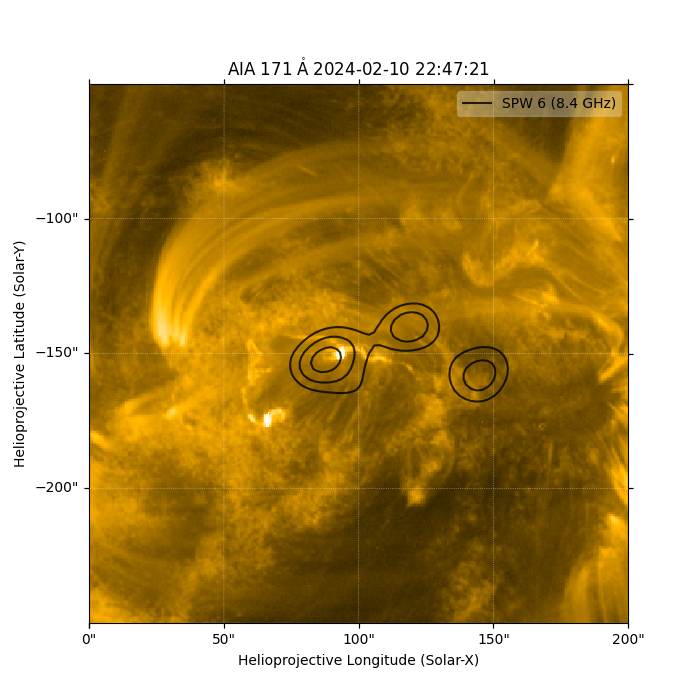

In [ ]:
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import astropy.units as u
import sunpy.map
import matplotlib.lines as mlines

# This script demonstrates how to plot open contours of EOVSA flare images
# for a specific spectral window (e.g., SPW 5) over an AIA image.

# ===========================
# Adjustable Parameters
# ===========================

# Define the region of interest around the flare site in arcseconds
x_range = [0, 200] * u.arcsec
y_range = [-250, -50] * u.arcsec

# Specify which spectral window (SPW) to plot
spw_index = 5  # SPW to visualize (e.g., SPW 5)
freq_ghz = cfreqs_ghz[spw_index]  # Central frequency of the selected SPW in GHz

# Define contour levels for plotting the EOVSA flare image (in percentage of max intensity)
levels = [50, 70, 90] * u.percent  # Intensity levels for contour plotting


# ===========================
# Plotting Block
# ===========================

# Initialize a figure with an AIA map projection
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': aia_map})

# Display the AIA map
aia_map.plot(axes=ax)

# Extract the specific SPW data from EOVSA
data = rdata[spw_index, :, :]
header = hdu[1].header
eomap = sunpy.map.Map(data, header)

# Plot open contours for the EOVSA flare image at specified intensity levels
# Set `fill=False` to plot open contours instead of filled ones
eomap.draw_contours(levels=levels, colors='black', fill=False, alpha=0.8, linewidths=1.5, axes=ax)

# Convert the region of interest from world coordinates to pixel coordinates
world_coords = SkyCoord(Tx=x_range, Ty=y_range, frame=aia_map.coordinate_frame)
pixel_coords_x, pixel_coords_y = aia_map.wcs.world_to_pixel(world_coords)

# Set plot limits to focus on the flare site
ax.set_xlim(pixel_coords_x)
ax.set_ylim(pixel_coords_y)

# ===========================
# Add Legend for Contours
# ===========================
# Comment out the following lines if you don't need a legend

# Create a line handle with the same properties as the contours
contour_handle = mlines.Line2D([], [], color='black', linestyle='-', linewidth=1.5, alpha=0.8)

# Add a single legend for all contours
ax.legend([contour_handle], [f'SPW {spw_index + 1} ({freq_ghz:.1f} GHz)'], loc='best', framealpha=0.3)

# Display the plot
plt.show()


#### Overlaying Multi-Frequency EOVSA Images on AIA

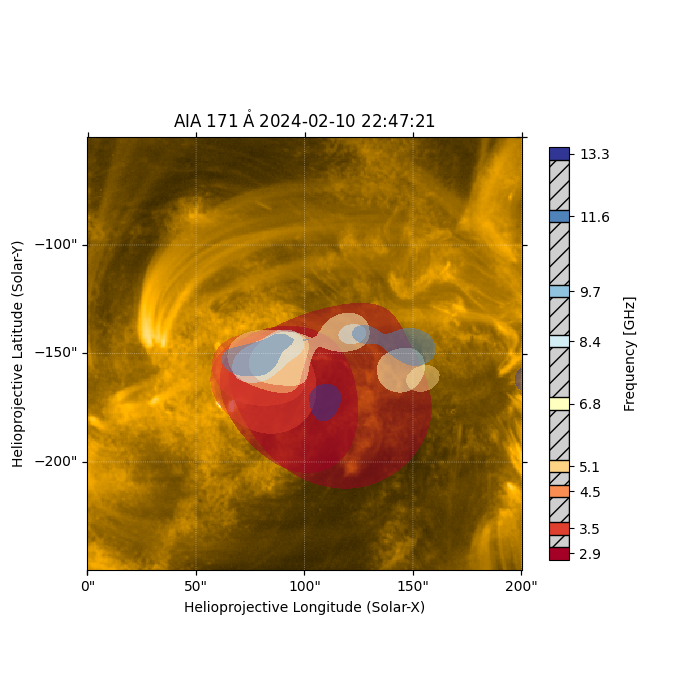

In [ ]:
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import astropy.units as u
import sunpy.map
import numpy as np
from matplotlib.colors import BoundaryNorm

# This script demonstrates how to overlay EOVSA flare images at multiple frequencies on an AIA image using filled contour plots.


# ===========================
# Adjustable Parameters
# ===========================

# Define the region of interest around the flare site in arcseconds
x_range = [0, 200] * u.arcsec
y_range = [-250, -50] * u.arcsec

# Define contour levels for plotting the EOVSA flare image (in percentage of max intensity)
levels = [50, 100] * u.percent

# Define the colormap for plotting the EOVSA flare images, which are colored according to their frequencies
colormap_name = 'RdYlBu'

# ===========================
# Setup Block
# ===========================

# Extract frequency information from the FITS file
cfreqs_ghz = hdu[2].data['cfreqs'] / 1e9  # Central frequencies of each spectral window in GHz
bdw_ghz = hdu[2].data['cdelts'] / 1e9  # Bandwidths of each spectral window in GHz
nfreqs = len(cfreqs_ghz)  # Number of frequencies

# Define frequency boundaries for the colorbar
lower_bounds = cfreqs_ghz - bdw_ghz / 2
upper_bounds = cfreqs_ghz + bdw_ghz / 2
boundaries = np.concatenate([lower_bounds, [upper_bounds[-1]]])

# Define a colormap and normalization for plotting
eocmap = plt.get_cmap(colormap_name, nfreqs)  # Discrete colormap for each spectral window
norm = BoundaryNorm(boundaries, ncolors=nfreqs)

# Normalize color values based on actual frequency values
min_freq, max_freq = cfreqs_ghz.min(), cfreqs_ghz.max()

# Define the frequency mask regions (gaps between SPW boundaries)
freqmask = [(upper_bounds[i], lower_bounds[i + 1]) for i in range(nfreqs - 1) if upper_bounds[i] < lower_bounds[i + 1]]

# Convert world coordinates to pixel coordinates for the AIA map
world_coords = SkyCoord(Tx=x_range, Ty=y_range, frame=aia_map.coordinate_frame)
pixel_coords_x, pixel_coords_y = aia_map.wcs.world_to_pixel(world_coords)

# ===========================
# Plotting Block
# ===========================

# Initialize a figure with an AIA map projection
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': aia_map})

# Display the AIA map
aia_map.plot(axes=ax)

# Loop over each spectral window to plot the EOVSA flare data
for s, freq in enumerate(cfreqs_ghz):
    data = rdata[s, :, :]
    header = hdu[1].header
    eomap = sunpy.map.Map(data, header)

    # Normalize the color based on the central frequency of the current SPW
    color_value = (freq - min_freq) / (max_freq - min_freq)
    color = eocmap(color_value)

    # Plot filled contours for the EOVSA flare image at specified intensity levels
    # Set `fill=True` to plot filled contours.
    eomap.draw_contours(levels=levels, colors=[color], fill=True, alpha=0.5, axes=ax)

# Set plot limits to focus on the flare site
ax.set_xlim(pixel_coords_x)
ax.set_ylim(pixel_coords_y)

# Add a discrete colorbar for the selected spectral windows
sm = plt.cm.ScalarMappable(cmap=eocmap, norm=norm)
sm.set_array([])

# Create the colorbar with appropriate boundaries and custom ticks
cbar = plt.colorbar(sm, ax=ax, boundaries=boundaries, spacing='proportional',
                    orientation='vertical', ticks=cfreqs_ghz, format='%.1f')
cbar.set_label('Frequency [GHz]', labelpad=10)

# Hide the minor ticks on the colorbar
cbar.ax.minorticks_off()

# Adjust the height of the colorbar to be 95% of the main plot height
ax_pos = ax.get_position()  # Get the original position of the main axis
cbar_ax = cbar.ax  # Get the colorbar axis

# Calculate new y position and height for the colorbar to align it with the plot
new_cbar_height = ax_pos.height * 0.95
new_cbar_y = ax_pos.y0 + (ax_pos.height - new_cbar_height) / 2
cbar_ax.set_position([cbar_ax.get_position().x0, new_cbar_y, cbar_ax.get_position().width, new_cbar_height])

# Add the frequency mask regions to the colorbar to highlight frequency gaps
for fbd_lo, fbd_hi in freqmask:
    cbar.ax.axhspan(fbd_lo, fbd_hi, hatch='//', edgecolor='k', facecolor='#CFCFCF')

# Display the plot
plt.show()
